# Particle in a Potential well

## Import libraries and set constants.

Here ``hbar`` and ``m`` where set to one to keep it simple.
The box width was set to ``1.``

In [1]:
import numpy as np
import matplotlib.pyplot as plt

hbar = 1.0 # planck
m = 1.0 # mass of particle
L = 1.0  # box length

## Analytic Eigenstates and Eigenenergies

A solution to the Schrödinger Equation with this Potential (infinite Potential_well) is given as $\psi_n(x) = \sqrt{\frac{2}{L}} \sin\left(\frac{n \pi x}{L}\right)$.

Define a function ``psi_n`` such that we can input the quantum number ``n`` and a spacial point ``x`` and we get the value of the Wave-function in the following form:
```pyhton
psi_n(n, x, L=1.0)
```

The energy levels are given by $E_n = \frac{n^2 \pi^2 \hbar^2}{2mL^2}$.

Now define a funciton ``E_n`` such that we can input the quantum number ``n`` and we get the energy associated with this quantum-number ``n``.
```python
E_n(n, L=1.0, hbar=1.0, m=1.0)
```

In [4]:
def E_n(n: int, L: float = 1.0, hbar: float = 1.0, m: float = 1.0):
    return (np.square(n) * np.square(np.pi) * np.square(hbar))/(2 * m * np.square(L))

Now try and call these functions with specific points here we will take ``x = 1`` and ``n = 0`` which is called the ground state.
Calculate the energy and value of psi_n for these values. At the edges ``psi(n, x=0 or x=L)`` psi should always be 0 because of the boundery conditions.

Note: In python sometimes 0 is written as a very small number as in 1e-16 because of machine calculation errors.


In [5]:
def psi_n(n: int, x: float, L: float = 1.0):
    return np.sqrt(2/L) * np.sin((n * np.pi * x)/L)

In [6]:
assert psi_n(n = 1, x = 1) < 0.0001 # very close to zero (computational error)
assert E_n(n = 0) == 0
assert E_n(n = 1) == 4.934802200544679
assert E_n(n = 2) == 19.739208802178716

## Plot eigenstates

Here we want to create pyplots for all given ``n`` values in a range from ``(1, 3)``.
We plug these ``n`` values into the psi_n function and create a plot using a 1D mesh as ``x`` while cycling through ``ns``.

### Step 1:

We want to create an ``x`` mesh so we have a list of ``x`` values we can plug into our ``psi_n`` function in order to plot those values.
Using the function ``np.linspace(x_start, x_end, steps)`` we can achieve exactly that. Here for our plots sake we will choose ``x_start = 0``.

Create this x-mesh where ``x_end = L`` and ``steps = 1200``.

In [9]:
x_start = 0
x_end = L
steps = 1200

x = np.linspace(x_start, x_end, steps)

In [10]:
assert len(x) == steps
assert x[0] == 0
assert x[-1] == L

### Step 2:

Now we want to create another list containing specific ``n`` values so we can then make an individual graph for every single ``psi_n`` corresponding to a value of ``n``.

We can achieve this using ``np.arange(n_start, n_end)``. For this example say we want plots for values of ``n`` from 1 to 4. So we have already set ``n_start`` to 1 and ``n_end`` to 4.

Create such a list using the given numpy function and call it ``ns``.

In [12]:
n_start = 1
n_end = 4
ns = np.arange(n_start, n_end)

In [13]:
assert ns[0] == 1
assert ns[-1] == 3

### Step 3:

Now we are ready to plot those graphs. The rough breakdown of how to make plots using ``matplotlib.pyplot`` is as follows:

- Create a figure to plot into using ``plt.figure``
- Create the plots inside this figure. In our case there will be multiple plots displayed in one figure so think of a smart way to loop over the elements of our ``ns`` list and create a plot for each value of ``n`` by calling the desired function (either ``psi_n`` or ``E_n``).
- Add a title by calling ``plt.title("YOUR TITLE")``
- Add a x-label by calling ``plt.xlabel("YOUR LABEL")``
- Add a y-label by calling ``plt.ylabel("YOUR LABEL")``
- Optionally add a legend by calling ``plt.legend()``
- Finally call ``plt.show()`` to display your newly created plot.

Go through this process for ``psi_n``.

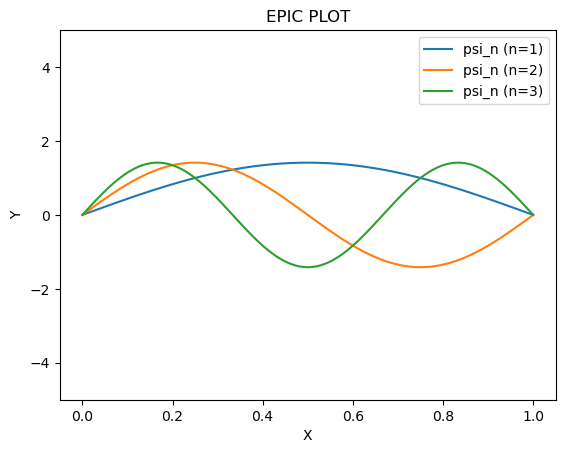

In [34]:
fig = plt.figure()
for n in ns:
    plt.plot(x, psi_n(n, x), label=f"psi_n (n={n})")
plt.title("EPIC PLOT")
plt.xlabel("X")
plt.ylabel("Y")
plt.ylim(-5, 5)
plt.legend()
plt.show()

## Energy plus Wavefunctions

To better understand what this looks like we can combine Energy and Wavefunktion into one Plot so we get the corresponding wave functions at each energy level ``E_n``.

You just need to run this to get the nice Plot:

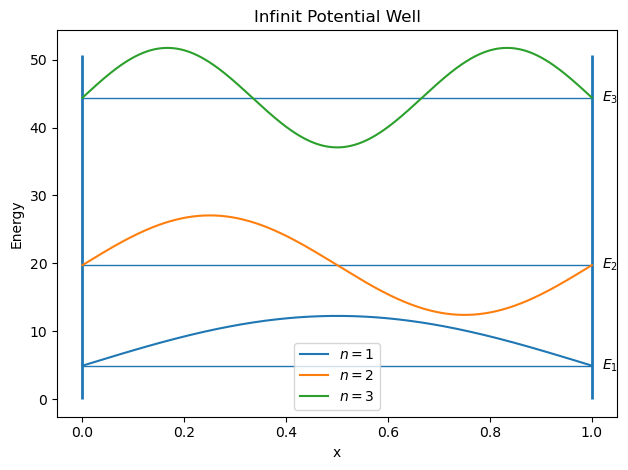

In [26]:
Es = np.array([E_n(n, L=L, hbar=hbar, m=m) for n in ns])

if len(Es) > 1:
    dE_min = np.min(np.diff(np.sort(Es)))
else:
    dE_min = Es[0]


A = 0.35 * dE_min # adjust the Amplitude for nice visualisation



# Indicate Wall
plt.vlines([0, L], ymin=0, ymax=Es.max() + 1.2*A, linewidth=2)

for n, En in zip(ns, Es):
    psi = psi_n(n, x, L=L)

    # Energyline
    plt.hlines(En, 0, L, linewidth=1)

    # Wavefunktion
    plt.plot(x, En + A * psi, label=fr"$n={n}$")

    # Small Text for indikation
    plt.text(L + 0.02*L, En, fr"$E_{n}$", va="center")

plt.xlabel("x")
plt.ylabel("Energy")

plt.title("Infinit Potential Well")
plt.legend()
plt.tight_layout()
plt.show()